In [1]:
# Exercise 5.1
# 1. Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe with respect to the column names and the variable types. 
import pandas as pd

# Read the file
bank = pd.read_csv("bank.csv", sep=";")

# Inspect the dataframe
print(bank.head())
print("\nColumns:")
print(bank.columns)

print("\nData types:")
print(bank.dtypes)

print("\nShape:")
print(bank.shape)

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact

In [5]:
# 2.Pick data from the following columns to a second dataframe df2: y, job, marital, default, housing, poutcome.
import pandas as pd

# Read the CSV file (note the semicolon delimiter)
df = pd.read_csv("bank.csv", sep=";")

# Create df2
df2 = df[['y', 'job', 'marital', 'default', 'housing', 'poutcome']]

print(df2.head())

    y          job  marital default housing poutcome
0  no   unemployed  married      no      no  unknown
1  no     services  married      no     yes  failure
2  no   management   single      no     yes  failure
3  no   management  married      no     yes  unknown
4  no  blue-collar  married      no     yes  unknown


In [6]:
# Convert categorical variables to dummy numerical values using the command df3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])

df3 = pd.get_dummies(
    df2,
    columns=['job', 'marital', 'default', 'housing', 'poutcome']
)

print(df3.head())

    y  job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  \
0  no       False            False             False          False   
1  no       False            False             False          False   
2  no       False            False             False          False   
3  no       False            False             False          False   
4  no       False             True             False          False   

   job_management  job_retired  job_self-employed  job_services  job_student  \
0           False        False              False         False        False   
1           False        False              False          True        False   
2            True        False              False         False        False   
3            True        False              False         False        False   
4           False        False              False         False        False   

   ...  marital_married  marital_single  default_no  default_yes  housing_no  \
0  ...      

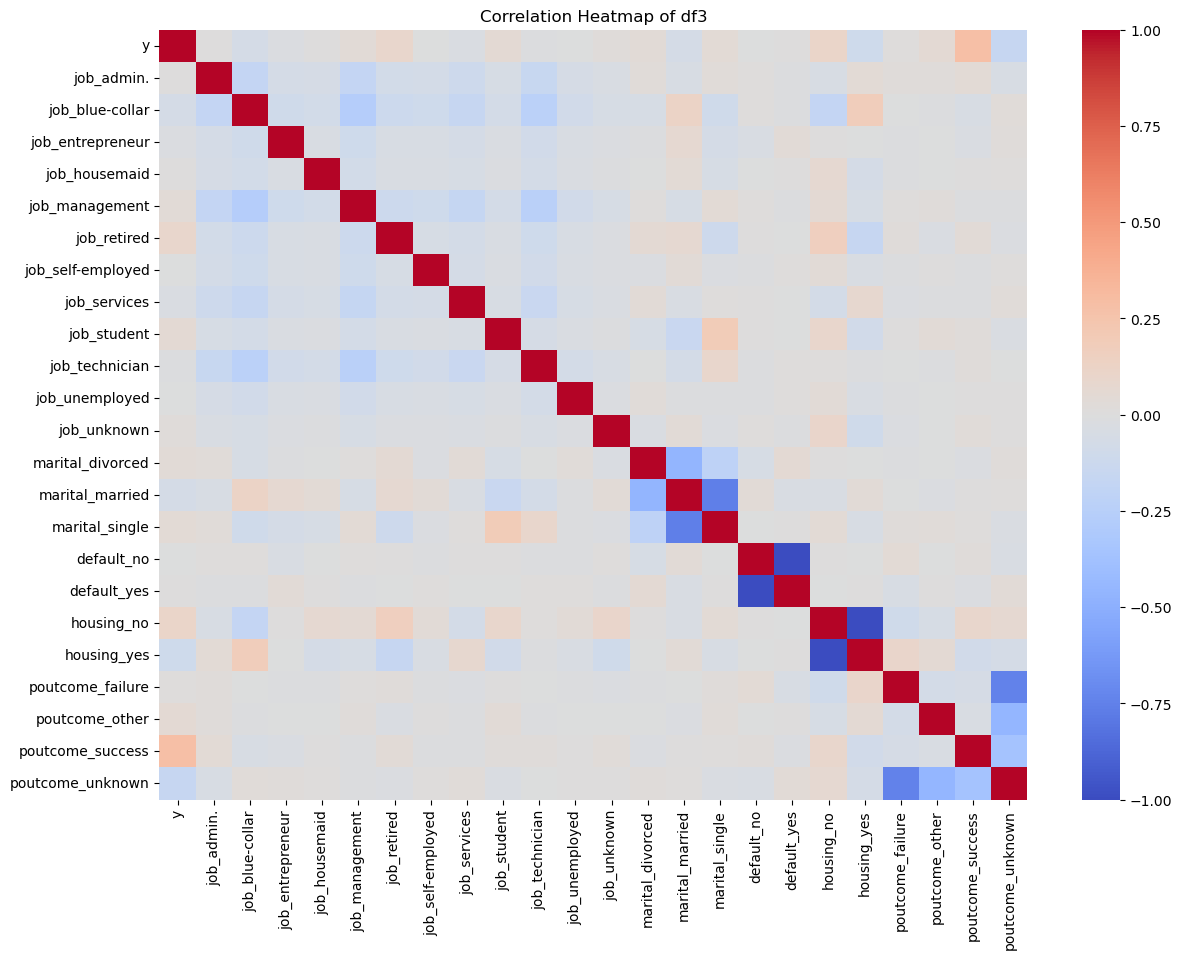

In [7]:
# Produce a heat map of correlation coefficients for all variables in df3. Describe the amount of correlation between the variables in your own words.

import matplotlib.pyplot as plt
import seaborn as sns

# If y is still yes/no, convert it first
df3['y'] = df3['y'].map({'no': 0, 'yes': 1})

# Correlation matrix
corr = df3.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of df3')
plt.show()

In [8]:
# 5. Select the column called y of df3 as the target variable y, and all the remaining columns for the explanatory variables X.

X = df3.drop(columns=['y'])
y = df3['y']

In [9]:
# 6. Split the dataset into training and testing sets with 75/25 ratio.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [23]:
# 7.Setup a logistic regression model, train it with training data and predict on testing data.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8972375690607735


Accuracy Score: 0.8972



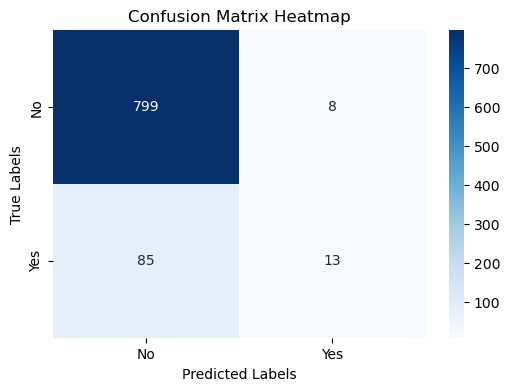

In [24]:
# 8.Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [39]:
#Exercise 5.2
#Consider the data from CSV file weight-height.csv.
#Read data into a pandas dataframe
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data directly from the repository
url = "https://raw.githubusercontent.com/johnmyleswhite/ML_for_Hackers/master/02-Exploration/data/01_heights_weights_genders.csv"
df = pd.read_csv(url)
df.columns = ['Gender', 'Height', 'Weight']

# 2. Separate dataframes for each gender
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

# 3. Print side-by-side descriptive statistics comparison
print("--- MALE STATISTICS ---")
print(male_df.describe())

print("\n--- FEMALE STATISTICS ---")
print(female_df.describe())

--- MALE STATISTICS ---
            Height       Weight
count  5000.000000  5000.000000
mean     69.026346   187.020621
std       2.863362    19.781155
min      58.406905   112.902939
25%      67.174679   173.887767
50%      69.027709   187.033546
75%      70.988744   200.357802
max      78.998742   269.989699

--- FEMALE STATISTICS ---
            Height       Weight
count  5000.000000  5000.000000
mean     63.708774   135.860093
std       2.696284    19.022468
min      54.263133    64.700127
25%      61.894441   122.934096
50%      63.730924   136.117583
75%      65.563565   148.810926
max      73.389586   202.237214


In [41]:
#2.Pick the target variable y as weight in kilograms, and the feature variable X as height in centimeters.

from sklearn.model_selection import train_test_split
X = df['Height']
y = df['Weight']

In [42]:
#3.Split the data into training and testing sets with 80/20 ratio.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:
#4.Scale the training and testing data using normalization and standardization.

from sklearn.preprocessing import MinMaxScaler, StandardScaler

norm_scaler = MinMaxScaler()
X_train_norm = norm_scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test_norm = norm_scaler.transform(X_test.values.reshape(-1, 1))
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test_std = std_scaler.transform(X_test.values.reshape(-1, 1))

In [44]:
#5. Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train.values.reshape(-1, 1), y_train)  
y_pred = knn.predict(X_test.values.reshape(-1, 1))
r2 = r2_score(y_test, y_pred)
print(" KNN Regression Performance (k=5)")
print("R² value:", r2)

 KNN Regression Performance (k=5)
R² value: 0.8346485438169171
